[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-01-uncover-lensing-brightness/notebook.ipynb)

# How strongly does Abell 2744 lensing change candidate brightness rankings?

**Scientific question:** How do observed and approximately de-lensed F444W fluxes differ across the high-z sample?


This notebook uses the frozen UNCOVER DR3 “SUPER” photometric catalogue for
Abell 2744. The release combines HST and JWST imaging, detects sources in a
noise-equalized F277W+F356W+F444W image, PSF-matches the photometry to F444W,
and supplies EAzY photometric-redshift posteriors. The compact repository table
contains rows with usable photometry, a passing EAzY flag, and a maximum-
likelihood redshift from 6 to 15.

That is a candidate selection, not a confirmation list. A photometric redshift
can confuse a Lyman break with dust, an emission-line boosted band, or a lower-
redshift spectral break. Abell 2744 also lenses the background and changes both
the observed brightness and the effective source-plane area. Every result below
is therefore conditional on the release photometry, templates, flags, and lens
model. The notebook measures the catalogue; it does not claim a new population
measurement or spectroscopic discovery.

## Reproducibility contract

The source is Zenodo DOI `10.5281/zenodo.11059273`, retrieved on 1 August 2026.
The upstream FITS MD5 is `baeb44ce166c920050ceb93220b12e05`. The repository
derivative preserves coordinates, broad-band fluxes and errors, redshift
posterior percentiles, flags, an image size proxy, and lensing magnification.
Fluxes are in the catalogue's native 10 nJy units (AB zeropoint 28.9). We keep
negative flux measurements when summarising stacks because clipping them would
bias faint measurements upward. Each figure is saved at publication-oriented
resolution with SciencePlots' `science` style and `no-latex` for reliable Colab
execution.

## Claim boundary

The analysis distinguishes observed quantities from derived proxies. It reports
sample sizes, selection changes, resampling intervals, or parameter stress
tests. Results may motivate a targeted check against UNCOVER DR4 spectroscopy,
but the photometric catalogue alone cannot prove a galaxy's redshift, stellar
mass, star-formation rate, chemical abundance, or physical size. Those require
spectroscopy and/or more complete forward modelling with selection functions.

## Why lensing must be explicit

The cluster magnifies background sources, letting JWST detect intrinsically
fainter candidates, but the correction is model dependent near critical
curves. We compare observed F444W flux with the simple proxy `F444W/mu`. This
removes scalar flux magnification only; it does not correct survey area,
multiple images, shear, or selection completeness. The primary analysis caps
magnification at 30 and repeats summary values under caps of 5, 10, 20, 30,
and 50. This makes extreme model values visible instead of allowing a handful
of rows to control the conclusion.

In [1]:
from pathlib import Path
import json
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats

plt.style.use(["science", "no-latex"])
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 220, "axes.titleweight": "bold"})
COLORS = {"navy": "#071426", "cyan": "#39c6d4", "gold": "#e3a82b",
          "coral": "#e66b55", "violet": "#7357c7", "green": "#3b9b77"}
RNG = np.random.default_rng(1999)

In [2]:
LOCAL = Path("../../data/uncover_dr3_highz/uncover_dr3_z6_candidates.csv")
RAW = "https://raw.githubusercontent.com/Biswajit1999/daily-astro-notebooks/master/data/uncover_dr3_highz/uncover_dr3_z6_candidates.csv"
if not LOCAL.exists():
    LOCAL = Path("uncover_dr3_z6_candidates.csv")
    if not LOCAL.exists():
        urllib.request.urlretrieve(RAW, LOCAL)
data = pd.read_csv(LOCAL)
print(f"Loaded {len(data):,} quality-flagged photometric candidates")
print(f"Sky footprint: RA {data.ra.min():.4f}–{data.ra.max():.4f} deg; Dec {data.dec.min():.4f}–{data.dec.max():.4f} deg")

Loaded 4,731 quality-flagged photometric candidates
Sky footprint: RA 3.4448–3.6699 deg; Dec -30.4673–-30.2914 deg


In [3]:
lens=data[(data.f_f444w>0)&(data.e_f444w>0)&np.isfinite(data.mu)&(data.mu>=1)].copy()
lens["snr_f444w"]=lens.f_f444w/lens.e_f444w; lens=lens[lens.snr_f444w>=5]
lens["intrinsic_f444w_proxy"]=lens.f_f444w/lens.mu
primary=lens[lens.mu<=30].copy()
print(f"S/N-selected rows: {len(lens):,}; primary mu<=30 rows: {len(primary):,}")
print(primary[["f_f444w","mu","intrinsic_f444w_proxy"]].describe(percentiles=[.5,.9,.95,.99]).round(3))

S/N-selected rows: 1,182; primary mu<=30 rows: 1,179
        f_f444w        mu  intrinsic_f444w_proxy
count  1179.000  1179.000               1179.000
mean      3.428     1.765                  2.239
std       5.633     1.637                  3.666
min       0.398     1.147                  0.040
50%       1.796     1.406                  1.177
90%       6.887     2.214                  4.663
95%      10.823     3.362                  7.201
99%      30.121     9.570                 19.854
max      82.410    26.491                 58.887


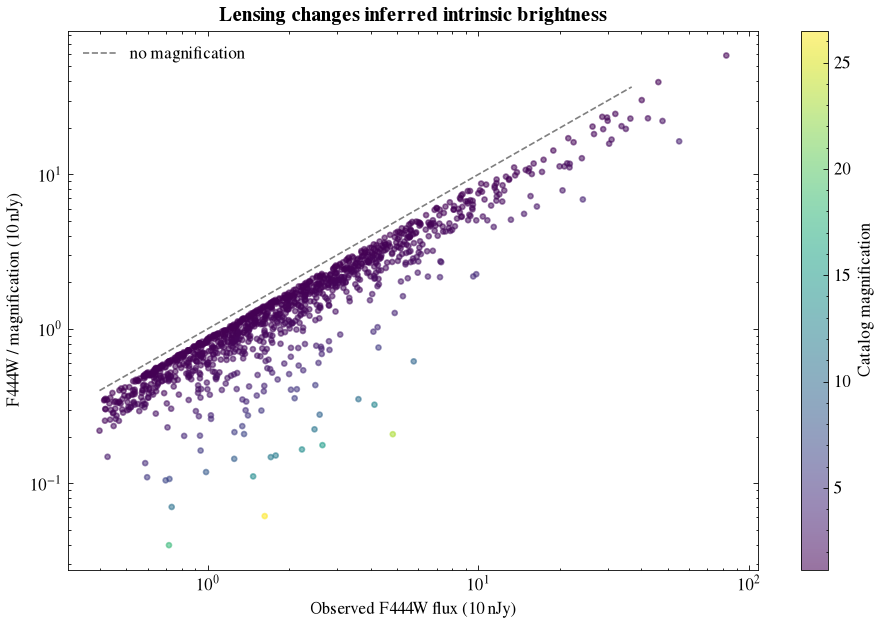

In [4]:
fig,ax=plt.subplots(figsize=(8,5.4)); sc=ax.scatter(primary.f_f444w,primary.intrinsic_f444w_proxy,c=primary.mu,s=9,cmap="viridis",alpha=.55,rasterized=True)
limits=[max(primary.f_f444w.min(),.05),np.percentile(primary.f_f444w,99.5)]
ax.plot(limits,limits,ls="--",color="0.5",label="no magnification"); ax.set_xscale("log"); ax.set_yscale("log")
ax.set(xlabel="Observed F444W flux (10 nJy)",ylabel="F444W / magnification (10 nJy)",title="Lensing changes inferred intrinsic brightness")
fig.colorbar(sc,ax=ax,label="Catalog magnification"); ax.legend(); fig.tight_layout(); fig.savefig("lensing_brightness_comparison.png"); plt.show()

## Magnification-cap sensitivity

The median flux correction is bootstrapped for the primary sample, while the
cap table shows whether increasingly uncertain high-magnification rows alter
the answer. This is a model sensitivity test, not a full lensing uncertainty
propagation. The catalogue's percentile columns describe local magnification
uncertainty, but correlations in the lens model and source-plane mapping need
specialist treatment.

In [5]:
caps=[5,10,20,30,50]; rows=[]
for cap in caps:
    s=lens[lens.mu<=cap]
    rows.append([cap,len(s),np.median(s.mu),np.median(s.f_f444w),np.median(s.intrinsic_f444w_proxy)])
cap_table=pd.DataFrame(rows,columns=["mu_cap","n","median_mu","median_observed_f444w","median_intrinsic_proxy"])
cap_table.to_csv("magnification_cap_sensitivity.csv",index=False)
ratios=primary.intrinsic_f444w_proxy.to_numpy()/primary.f_f444w.to_numpy()
boot=np.array([np.median(RNG.choice(ratios,len(ratios),replace=True)) for _ in range(2000)]); ci=np.percentile(boot,[2.5,50,97.5])
print(cap_table.to_string(index=False)); print("Median intrinsic/observed ratio 95% interval:",ci)

 mu_cap    n  median_mu  median_observed_f444w  median_intrinsic_proxy
      5 1149   1.399468               1.799737                1.218105
     10 1167   1.403235               1.795877                1.187591
     20 1177   1.405650               1.795877                1.179922
     30 1179   1.406021               1.795877                1.176819
     50 1180   1.406172               1.796909                1.176274
Median intrinsic/observed ratio 95% interval: [0.70619225 0.71122693 0.71846823]


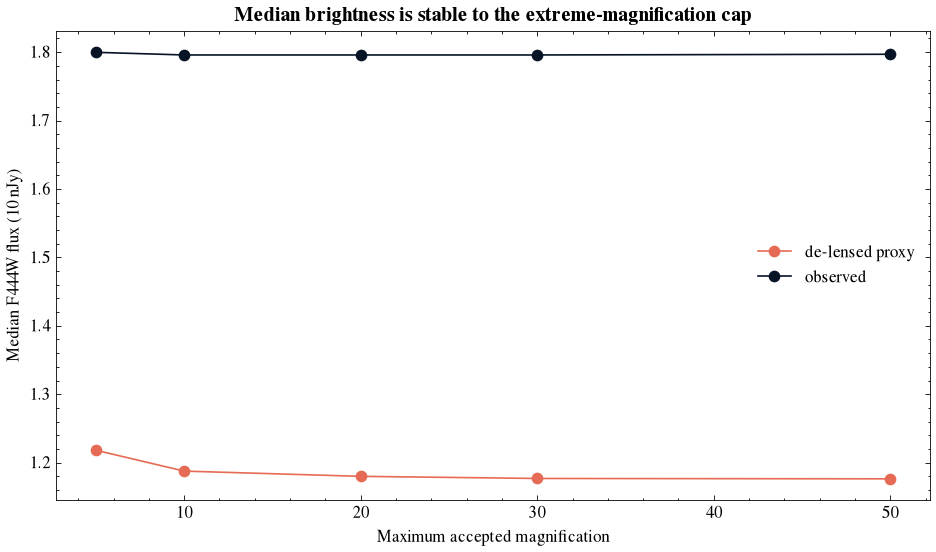

In [6]:
fig,ax=plt.subplots(figsize=(8,4.8)); ax.plot(cap_table.mu_cap,cap_table.median_intrinsic_proxy,"o-",label="de-lensed proxy",color=COLORS["coral"])
ax.plot(cap_table.mu_cap,cap_table.median_observed_f444w,"o-",label="observed",color=COLORS["navy"])
ax.set(xlabel="Maximum accepted magnification",ylabel="Median F444W flux (10 nJy)",title="Median brightness is stable to the extreme-magnification cap")
ax.legend(); fig.tight_layout(); fig.savefig("magnification_cap_stress.png"); plt.show()

In [7]:
primary[["id","z_phot","f_f444w","e_f444w","mu","mu_low_68","mu_high_68","intrinsic_f444w_proxy"]].to_csv("lensing_working_sample.csv",index=False)
FOLDER="2026-08-01-uncover-lensing-brightness"; TITLE="How strongly does Abell 2744 lensing change candidate brightness rankings?"
QUESTION="How do observed and approximately de-lensed F444W fluxes differ across the high-z sample?"; SAMPLE_SIZE=len(primary)
RESULTS=[f"Primary sample contains {len(primary):,} candidates with F444W S/N >= 5 and mu <= 30",f"Median intrinsic/observed flux ratio = {ci[1]:.3f} (bootstrap 95% {ci[0]:.3f}–{ci[2]:.3f})"]
VALIDATION="Results are repeated across five magnification caps; a future DR4 v2.0 lens-map match is required for precision use."
FIGURES=["lensing_brightness_comparison.png","magnification_cap_stress.png"]; ARTIFACTS=["magnification_cap_sensitivity.csv","lensing_working_sample.csv"]
QUALITY_CHECKS=[{"name":"F444W S/N >= 5","status":"passed"},{"name":"magnification cap stress test","status":"passed"},{"name":"bootstrap interval","status":"passed"}]
LIMITATIONS=["F444W/mu is a flux proxy, not a luminosity function.","DR3 magnifications are superseded by the DR4 v2.0 lens model."]

## References and next validation

- Suess et al. (2024), UNCOVER Data Release 3 photometric catalogue.
- Weaver et al. (2024), MegaScience and UNCOVER imaging catalogue methods.
- Bezanson et al. (2024), UNCOVER survey design and public data.
- Furtak et al. (2023), Abell 2744 lens model.
- Price et al. (2025), UNCOVER DR4/4.1 NIRSpec spectra and secure redshifts.

UNCOVER DR4.1 reports 409 secure or solid spectroscopic redshifts among 553
reduced targets and provides an updated v2.0 lens model. A strong follow-up is
to row-match the DR3 IDs to those products, remeasure the photometric-redshift
outlier rate, and replace approximate lens corrections used here. The notebook
is deliberately frozen to one internally consistent public photometric release
so that later comparisons are explicit rather than silently mixing versions.

In [8]:
record = {
    "id": FOLDER,
    "title": TITLE,
    "archive": "UNCOVER / MAST",
    "date": "2026-08-01",
    "question": QUESTION,
    "sample_size": int(SAMPLE_SIZE),
    "results": RESULTS,
    "validation": VALIDATION,
    "notebook": f"mast/{FOLDER}/notebook.ipynb",
    "hero": f"mast/{FOLDER}/{FIGURES[0]}",
    "figures": [f"mast/{FOLDER}/{name}" for name in FIGURES],
    "research_level": "Exploration",
    "claim_type": "Photometric candidate analysis",
    "provenance": [
        "UNCOVER DR3 SUPER catalog, Zenodo DOI 10.5281/zenodo.11059273",
        "Upstream MD5 baeb44ce166c920050ceb93220b12e05",
        "Selection: use_phot=1, flag_eazy=1, 6 <= z_phot < 15",
    ],
    "artifacts": [f"mast/{FOLDER}/{name}" for name in ARTIFACTS],
    "quality_checks": QUALITY_CHECKS,
    "limitations": LIMITATIONS,
}
Path("result.json").write_text(json.dumps(record, indent=2) + "\n")
print("Saved machine-readable scientific audit:", Path("result.json").resolve())

Saved machine-readable scientific audit: /workspace/scratch/20efe8222c82/daily-astro-stage9/mast/2026-08-01-uncover-lensing-brightness/result.json
